# Data Loading and Initial Cleaning

In this notebook, I loaded multiple datasets:
- Three election source datasets (in a mix of Parquet and CSV formats).
- The full entity and relationship extraction results from the LLM.

Some datasets had inconsistent formats and columns. I standardized the column names and structures to ensure consistency across all datasets.

Key steps:
- Added a **source tag** to each article to track its origin.
- Cleaned and standardized the **`is_relevant`** column for consistency.
- Merged the article text data across datasets.
- Incorporated previously failed articles from the LLM extraction to ensure comprehensive coverage.

This resulted in a unified **text DataFrame** ready for further EDA and feature engineering.

In [1]:
import pandas as pd

# Load datasets
us = pd.read_csv("/Users/ghadena/Desktop/geopol/data/raw/us_df.csv")
german = pd.read_parquet("/Users/ghadena/Desktop/geopol/data/raw/urls.parquet")
french = pd.read_parquet("/Users/ghadena/Desktop/geopol/data/raw/french_election_texts.parquet")
entities = pd.read_csv("/Users/ghadena/Desktop/geopol/data/processed/entites_n_relationships.csv")


# Add source tags
us['source'] = 'us'
german['source'] = 'german'
french['source'] = 'french'

# --- Step 1: US relevance flag ---
us['is_relevant'] = (us['relevance_text'] == 1).astype("Int64") 
# Rename text column
if 'text' in us.columns:
    us.rename(columns={'text': 'article_text'}, inplace=True)
us.drop(columns=[
    'is_us_election', 'is_french_election', 'is_german_election',
    'relevance_text', 'relevance_description', 'text', 'Unnamed: 0'
], inplace=True, errors='ignore')

# --- Step 2: Create relevance lookup from entities ---
relevance_lookup = entities[['url', 'relevant_to_german_or_french_elections']].copy()

# Clean and convert to boolean: "true" → 1, everything else → 0
# Step 2: Clean and convert to 0 / 1 / NaN
relevance_lookup['is_relevant'] = (
    relevance_lookup['relevant_to_german_or_french_elections']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(lambda x: 1 if x == 'true' else (0 if x == 'false' else pd.NA))
).astype("Int64") 

# Keep only what we need
relevance_lookup = relevance_lookup[['url', 'is_relevant']]

# --- Step 3: Merge into German & French ---
german = german.merge(relevance_lookup, on='url', how='left')
french = french.merge(relevance_lookup, on='url', how='left')

# Do NOT fill nulls — let is_relevant be NaN if URL not in entities

# --- Step 4: Combine all articles ---
texts = pd.concat([us, french, german], ignore_index=True)


## merging the articles i redid 

In [2]:

extracted = pd.read_csv('/Users/ghadena/Desktop/geopol/notebooks/redo_tomerge.csv')
redo_this = pd.read_csv('/Users/ghadena/Desktop/geopol/notebooks/redo_this.csv')

# Assuming your common key column is 'url', let's merge based on it:
redo_this = redo_this.drop(columns=['is_relevant']).merge(
    extracted[['url', 'is_relevant']],
    on='url',
    how='left'
)

redo_this = redo_this.dropna(subset=['is_relevant', 'datetime'])
redo_this = redo_this.drop(columns=['Unnamed: 0','used_description_as_text'])

In [3]:
redo_this.is_relevant.value_counts()

is_relevant
0.0    341
1.0    186
Name: count, dtype: int64

In [27]:
texts = pd.concat([us, french, german, redo_this], ignore_index=True)

# EDA and Cleaning

EDA and cleaning were performed concurrently.

Key steps:
- Analyzed the distribution of the `is_relevant` variable.
- Inspected articles with empty or null text fields.
- Investigated articles with null `is_relevant` values.
- Examined null counts broken down by source.
- Identified and removed duplicate articles.
- Analyzed the language distribution across articles.

This initial cleaning ensured better data consistency and quality for downstream analysis.

In [28]:
texts.columns

Index(['url', 'datetime', 'language', 'description', 'article_text', 'source',
       'is_relevant'],
      dtype='object')

relevant distribution 

In [29]:
texts.is_relevant.value_counts(normalize=True)

is_relevant
0.0    0.807114
1.0    0.192886
Name: proportion, dtype: Float64

In [30]:
# --- 10. Check % relevant articles by source ---
relevance_by_source = (
    texts.groupby('source')['is_relevant']
    .mean()
    .mul(100)
    .round(2)
    .rename('% Relevant')
)
print("📊 % Relevant articles by source:")
print(relevance_by_source)

# --- 11. Check missing article_text (NaN or empty) ---
missing_text = texts[
    texts['article_text'].isna() |
    (texts['article_text'].astype(str).str.strip() == '')
]
print(f"\n🛑 Articles with empty text: {len(missing_text)}")


📊 % Relevant articles by source:
source
french    19.96
german    10.54
us        26.15
Name: % Relevant, dtype: Float64

🛑 Articles with empty text: 1602


In [31]:
texts.shape

(7114, 7)

null article texts - create flag

In [32]:
null_articles = texts[
    texts['article_text'].isna() |
    (texts['article_text'].astype(str).str.strip() == '')
]
null_articles

,url,datetime,language,description,article_text,source,is_relevant
3,https://www.nytimes.com/video,2025-04-21,en,"Last December, video emerged showing the bodie...",NaN,us,0.0
32,https://www.cnn.com/2024/09/06/europe/video-ru...,2024-09-06,en,"The troops stagger onto a dusty track, then on...",NaN,us,0.0
123,https://www.reuters.com/world/europe/books-scr...,2024-09-10,en,"This autumn, pupils in the Finnish town of Rii...",NaN,us,0.0
264,https://www.npr.org/2024/09/19/g-s1-23689/insi...,2024-09-19,en,"As they fought to keep Sean ""Diddy"" Combs out ...",NaN,us,0.0
274,https://www.bbc.com/news/articles/cz04m913m49o,2024-09-20,en,Details about the walkie-talkies detonated in ...,NaN,us,0.0
...,...,...,...,...,...,...,...
6780,https://apnews.com/article/wall-street-stocks-...,2025-05-08T00:00:00.0000000,en,U.S. stocks rose after the United States and U...,NaN,french,0.0
6781,https://apnews.com/article/trump-tariff-englan...,2025-05-08T00:00:00.0000000,en,NEW YORK (AP) — Long-threatened tariffs from U...,NaN,french,0.0
6782,https://apnews.com/article/stream-tv-music-mov...,2025-04-28T00:00:00.0000000,en,NEW YORK (AP) — Blake Lively and Anna Kendrick...,NaN,french,0.0
6805,https://www.politico.eu/podcast/berlin-playboo...,2025-04-02T04:46:00.0000000,de,– Merz plant das Super-Kanzleramt: Der vorauss...,NaN,french,1.0


In [33]:
null_counts_by_source = null_articles['source'].value_counts()
print(null_counts_by_source)

source
french    1205
german     365
us          32
Name: count, dtype: int64


In [34]:
null_articles.is_relevant.value_counts()

is_relevant
0.0    1188
1.0     107
Name: count, dtype: Int64

In [35]:
# Flag articles where article_text is missing or empty
texts['used_description_as_text'] = (
    texts['article_text'].isna() |
    (texts['article_text'].astype(str).str.strip() == '')
).astype(int)

duplicates 

In [36]:
duplicates = texts[texts.duplicated()]
print(f"Number of duplicate rows based on all columns: {len(duplicates)}")
duplicates.head()

Number of duplicate rows based on all columns: 60


,url,datetime,language,description,article_text,source,is_relevant,used_description_as_text
1207,https://www.politico.eu/newsletter/politico-eu...,2024-10-17,en,"By ELISA BRAUN. Tips, tales, traumas to @elisa...","A weekly newsletter on campaigning, lobbying a...",us,0.0,0
1217,https://www.politico.eu/article/italy-germany-...,2024-10-15,en,The chair position is for four years but can b...,The chair position is for four years but can b...,us,0.0,0
2913,https://www.bfmtv.com/grand-lille/sport/ligue-...,2025-05-18T00:00:00.0000000,fr,VIDÉO - Le multiplex de cette dernière journée...,Ligue 1: revivez le but de Rémy Canella\n\nLe ...,french,0.0,0
2930,https://www.bfmtv.com/international/europe/ukr...,2025-05-18T00:00:00.0000000,fr,"Le vice-président des États-Unis, JD Vance, et...","Le vice-président des États-Unis, JD Vance, et...",french,0.0,0
2931,https://www.bfmtv.com/replay-emissions/affaire...,2025-05-18T00:00:00.0000000,fr,"VIDÉO - Chaque week-end, l’émission pilotée pa...",Jubillar : la vérité grâce à la téléphonie ? -...,french,0.0,0


In [37]:
url_duplicates = texts[texts.duplicated(subset=['url'], keep=False)]
print(f"Number of duplicate rows based on 'url': {len(url_duplicates)}")
url_duplicates.sort_values('url').head(10)

Number of duplicate rows based on 'url': 1253


,url,datetime,language,description,article_text,source,is_relevant,used_description_as_text
4013,https://apnews.com/article/abigail-disney-elev...,2025-05-13T23:16:07.0000000,en,"MIAMI BEACH, Florida (AP) — Activist and phila...",,french,<NA>,1
6774,https://apnews.com/article/abigail-disney-elev...,2025-05-13T23:16:07.0000000,en,"MIAMI BEACH, Florida (AP) — Activist and phila...",NaN,french,0.0,1
6067,https://apnews.com/article/aptopix-best-photos...,2025-04-12T00:00:00.0000000,en,55 of 64 | . Currency traders work near a scre...,,german,<NA>,1
3881,https://apnews.com/article/aptopix-best-photos...,2025-04-12T00:00:00.0000000,en,55 of 64 | . Currency traders work near a scre...,,french,<NA>,1
6692,https://apnews.com/article/aptopix-best-photos...,2025-04-12T00:00:00.0000000,en,55 of 64 | . Currency traders work near a scre...,NaN,french,0.0,1
3883,https://apnews.com/article/aptopix-best-photos...,2025-04-19T00:00:00.0000000,en,This is a photo collection curated by AP photo...,,french,<NA>,1
6694,https://apnews.com/article/aptopix-best-photos...,2025-04-19T00:00:00.0000000,en,This is a photo collection curated by AP photo...,NaN,french,0.0,1
6720,https://apnews.com/article/aptopix-best-photos...,2025-04-26T00:00:00.0000000,en,15 of 85 | . A boy holds a copy of the Holy Qu...,NaN,french,0.0,1
3921,https://apnews.com/article/aptopix-best-photos...,2025-04-26T00:00:00.0000000,en,15 of 85 | . A boy holds a copy of the Holy Qu...,,french,<NA>,1
6686,https://apnews.com/article/associated-press-to...,2025-04-16T00:00:00.0000000,en,"Marion Calder, right, and Susan Smith, left, f...",NaN,french,0.0,1


In [38]:
texts = texts.drop_duplicates(subset=['url'], keep='last')

In [39]:
print(texts.shape)

(6450, 8)


is relevant column - dropped 

In [40]:
# Check how many and what sources have missing relevance info
is_relevant_nulls = texts[texts['is_relevant'].isna()]
print(f"🔍 Articles with null is_relevant: {len(is_relevant_nulls)}")

# Count by source
print("By source:")
print(is_relevant_nulls['source'].value_counts())

# Preview
is_relevant_nulls[['url', 'source', 'language', 'article_text', 'description']].head()

🔍 Articles with null is_relevant: 82
By source:
source
french    65
german    17
Name: count, dtype: int64


,url,source,language,article_text,description
3858,https://apnews.com/article/ahmad-alsharaa-trum...,french,en,,President Donald Trump says he will ease sanct...
3860,https://apnews.com/article/kashmir-india-pakis...,french,en,,Trump touts a possible ‘solution’ for Kashmir ...
3862,https://apnews.com/article/gaza-humanitarian-a...,french,en,,UNITED NATIONS (AP) — The United Nations’ top ...
3867,https://apnews.com/article/stock-markets-earni...,french,en,,Businesses continue to trim or withdraw their ...
3876,https://apnews.com/article/indonesia-army-ammu...,french,en,,"JAKARTA, Indonesia (AP) — An explosion during ..."


In [41]:
is_relevant_nulls.sample(5).description.to_list()

['Earthjustice attorney Jeffrey Stein said Tuesday scrubbing the websites of information relevant to programs it was undoing “made it really difficult for farmers to fight for the funding that they’re owed, for advocates to educate the public and members of Congress about the specific impacts of freezing funding on ordinary Americans in their districts.”',
 'CINCINNATI (AP) — Miguel Vargas hit a three-run homer in the 10th inning, and the Chicago White Sox beat the Cincinnati Reds 5-1 Tuesday night in a game delayed nearly two hours at the start because of rain.. Cincinnati’s Elly De La Cruz hit a 435-foot solo homer, his seventh, to tie the game in the bottom of the ninth.',
 'BALTIMORE (AP) — Flooding in rural western Maryland forced the evacuation of an elementary school Tuesday afternoon as water began to breach the second floor, according to local officials.',
 'ANKARA, Turkey (AP) — Turkey is closely monitoring any attempts to undermine its peace initiative with the PKK, a senior

In [43]:
texts = texts.dropna(subset=['is_relevant'])
texts.shape

(6368, 8)

language 

In [44]:
allowed_langs = ['en', 'de', 'fr']
texts = texts[texts['language'].isin(allowed_langs)].reset_index(drop=True)

In [95]:
texts.language.value_counts()

language
en    4692
de    1029
fr     645
Name: count, dtype: int64

In [96]:
texts.groupby('source').language.value_counts()

source  language
french  en          1444
        fr           610
        de             1
german  de          1025
        en           946
        fr            26
us      en          2302
        fr             9
        de             3
Name: count, dtype: int64

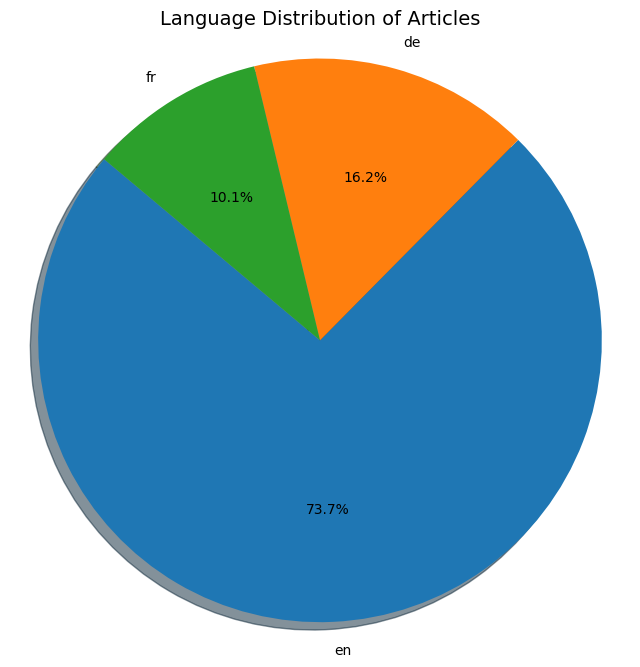

In [98]:
import matplotlib.pyplot as plt

# Language distribution counts
lang_counts = texts['language'].value_counts()

# Plotting a pie chart
plt.figure(figsize=(8, 8))
plt.pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', startangle=140, shadow=True)
plt.title('Language Distribution of Articles', fontsize=14)
plt.axis('equal')  # Ensures pie chart is drawn as a circle.

plt.show()

In [45]:
texts.shape

(6366, 8)

# Merging with Entity Data and Further Cleaning

Next, I merged the cleaned **text DataFrame** with the **entities DataFrame** to enrich articles with extracted entities. 

Key steps:
- Dropped articles without matching entity extractions.
- Analyzed the `datetime` distribution and identified null values.
- Reviewed the overall distribution of article publication dates.
- Created flag variables to assist in feature engineering.
- Analyzed extraction coverage per article.

In [64]:
# Load entities if not already in memory
entities1 = pd.read_csv("/Users/ghadena/Desktop/geopol/data/processed/entites_n_relationships.csv")
entities2 = pd.read_csv('/Users/ghadena/Desktop/geopol/notebooks/redo_tomerge.csv')

entities = pd.concat([entities1, entities2], ignore_index=True)

# Drop any duplicate URLs in entities (just to be safe)
entities = entities.drop_duplicates(subset='url')
entities = entities.drop(columns=['relevant_to_german_or_french_elections', 'is_relevant', 'lang', 'Unnamed: 0'])

# Merge texts with entities on 'url'
merged = texts.merge(entities, on='url', how='left', indicator=True)

In [65]:

merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   url                       6366 non-null   object  
 1   datetime                  6366 non-null   object  
 2   language                  6366 non-null   object  
 3   description               6366 non-null   object  
 4   article_text              6138 non-null   object  
 5   source                    6366 non-null   object  
 6   is_relevant               6366 non-null   Float64 
 7   used_description_as_text  6366 non-null   int64   
 8   extracted_entities        6319 non-null   object  
 9   entity_relationships      6319 non-null   object  
 10  _merge                    6366 non-null   category
dtypes: Float64(1), category(1), int64(1), object(8)
memory usage: 510.0+ KB


check unmatched rows and drop 

In [60]:
# Check how many articles didn't get matched
unmatched = merged[merged['_merge'] == 'left_only']
print(f"🟡 Unmatched articles: {len(unmatched)}")


🟡 Unmatched articles: 47


In [63]:
merged.columns

Index(['url', 'datetime', 'language', 'description', 'article_text', 'source',
       'is_relevant', 'used_description_as_text', 'extracted_entities',
       'entity_relationships'],
      dtype='object')

In [66]:

# 1. Drop unmatched rows (only keep rows that were matched during merge)
merged = merged[merged['_merge'] == 'both'].reset_index(drop=True)


merged.drop(columns=[ '_merge'], inplace=True, errors='ignore')


In [67]:
merged.shape

(6319, 10)

datetime 

In [76]:
merged["datetime"] = merged["datetime"].apply(
    lambda x: pd.to_datetime(x, errors='coerce') if pd.notna(x) else pd.NaT
)

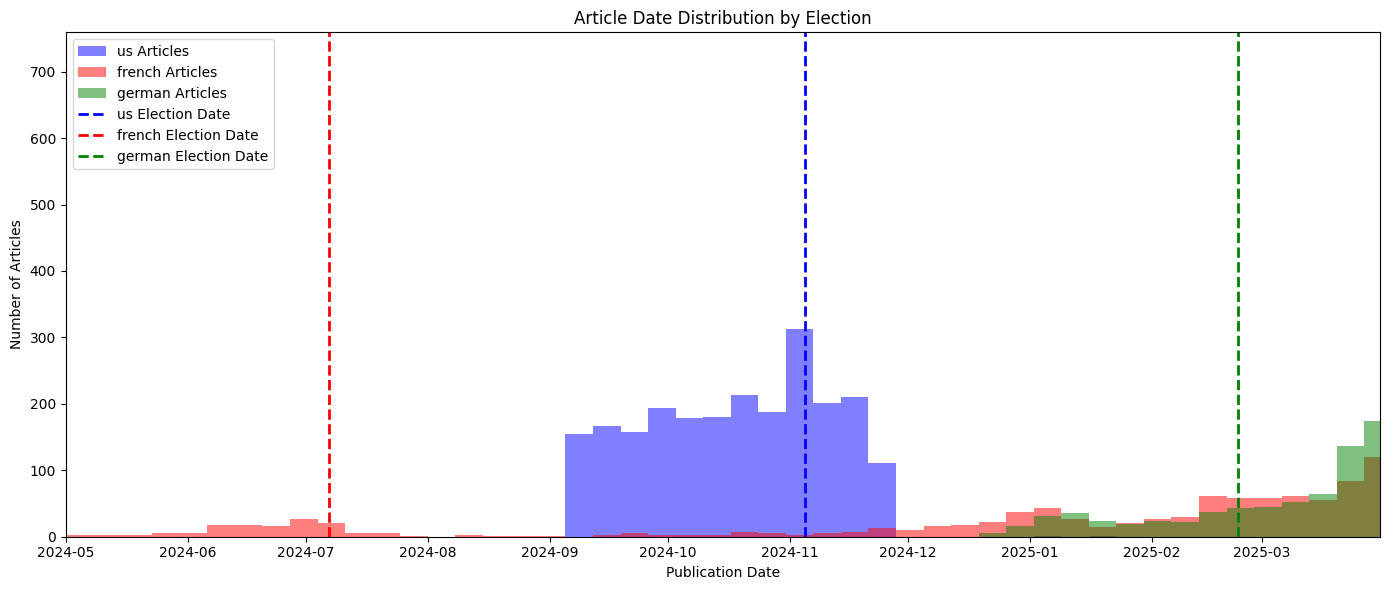

In [83]:
import matplotlib.pyplot as plt

# Election dates
election_dates = {
    'us': pd.to_datetime("2024-11-05"),
    'french': pd.to_datetime("2024-07-07"),
    'german': pd.to_datetime("2025-02-23")
}

# Colors for consistency
colors = {
    'us': 'blue',
    'french': 'red',
    'german': 'green'
}

# 3. Uniform binning: bin size = 7 days (weekly bins)
bin_size = '7D'  # could be '10D' or '14D' if you want larger
min_date = merged['datetime'].min()
max_date = merged['datetime'].max()

# Create custom bin edges
bins = pd.date_range(start=min_date, end=max_date + pd.Timedelta(days=7), freq=bin_size)

plt.figure(figsize=(14, 6))

# 4. Plot histograms
for election_name in ['us', 'french', 'german']:
    subset = merged[merged['source'] == election_name]
    plt.hist(
        subset['datetime'], 
        bins=bins, 
        alpha=0.5, 
        label=f"{election_name} Articles", 
        color=colors[election_name],
        density=False
    )

# 5. Plot election dates
for name, date in election_dates.items():
    plt.axvline(
        x=date, 
        color=colors[name], 
        linestyle='--', 
        linewidth=2, 
        label=f"{name} Election Date"
    )

# 6. Zoom into reasonable date range
plt.xlim([pd.to_datetime('2024-05-01'), pd.to_datetime('2025-03-31')])  # Adjust based on your data

# Labels and Title
plt.xlabel('Publication Date')
plt.ylabel('Number of Articles')
plt.title('Article Date Distribution by Election')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
import pandas as pd

# Election dates
election_dates = {
    'us': pd.to_datetime("2024-11-05"),
    'french': pd.to_datetime("2024-07-07"),
    'german': pd.to_datetime("2025-02-23")
}

# Function to compute pre- and post-election counts
def count_pre_post(df, election_name, election_date):
    subset = merged[merged['source'] == election_name]
    pre = subset[subset['datetime'] < election_date].shape[0]
    post = subset[subset['datetime'] >= election_date].shape[0]
    total = subset.shape[0]
    return pre, post, total

# Build table
results = []
for election_name, election_date in election_dates.items():
    pre, post, total = count_pre_post(merged, election_name, election_date)
    results.append({
        'Election': election_name,
        'Pre-election Articles': pre,
        'Post-election Articles': post,
        'Total Articles': total
    })

results_df = pd.DataFrame(results)

results_df

,Election,Pre-election Articles,Post-election Articles,Total Articles
0,us,1569,698,2267
1,french,110,1942,2055
2,german,239,1746,1997


In [92]:
merged['date'] = merged['datetime'].dt.date
merged.groupby(['source','is_relevant']).date.describe()

/var/folders/nx/lwphb_yx3312gqm2v4zgwnr00000gn/T/ipykernel_52551/1788718306.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['date'] = merged['datetime'].dt.date


count unique         top freq
source is_relevant                              
french 0.0          1620    202  2025-05-18  165
       1.0           431    168  2025-05-18   13
german 0.0          1776    119  2025-04-14  143
       1.0           209     57  2025-04-09   21
us     0.0          1671     83  2024-11-21   53
       1.0           596     77  2024-11-05   75

In [93]:
merged.groupby(['source','is_relevant']).datetime.describe()

count                           mean                  min  \
source is_relevant                                                             
french 0.0          1620  2025-03-27 20:16:22.627777536  2024-05-06 00:00:00   
       1.0           431  2024-12-29 14:13:52.204176384  2024-04-30 00:00:00   
german 0.0          1776  2025-03-28 12:00:43.179617024  2024-12-23 00:00:00   
       1.0           209  2025-03-23 23:33:20.569377792  2024-01-10 22:54:46   
us     0.0          1671  2024-10-16 01:34:47.612208384  2024-09-05 00:00:00   
       1.0           596  2024-10-24 07:53:33.422818816  2024-09-05 00:00:00   

                                    25%                  50%  \
source is_relevant                                             
french 0.0          2025-03-07 00:00:00  2025-04-11 01:31:00   
       1.0          2024-07-09 00:00:00  2025-02-24 15:18:00   
german 0.0          2025-03-24 00:00:00  2025-04-08 00:00:00   
       1.0          2025-03-22 00:00:00  2025-04-09 00:00:00   
us     0.0          2024-09-26 00:00:00  2024-10-16 00:00:00   
       1.0          2024-10-12 00:00:00  2024-11-04 00:00:00   

                                    75%                  max  
source is_relevant                                            
french 0.0          2025-05-13 00:00:00  2025-05-18 20:10:00  
       1.0          2025-04-08 00:00:00  2025-05-18 13:36:00  
german 0.0          2025-04-14 00:00:00  2025-05-15 00:00:00  
       1.0          2025-04-13 00:00:00  2025-04-21 00:00:00  
us     0.0          2024-11-04 12:00:00  2025-04-21 00:00:00  
       1.0          2024-11-07 00:00:00  2024-11-23 00:00:00

drop 2018 outliar 

In [91]:
merged = merged[merged['datetime'] != '2018-03-01']
merged['datetime'].min()

Timestamp('2024-01-10 22:54:46')

flags 

In [68]:
# 3. Add flags: has_entities and has_relationships
import json
import ast

def is_non_empty_entity_dict(value):
    try:
        data = ast.literal_eval(value) if isinstance(value, str) else value
        if isinstance(data, dict):
            return any(len(v) > 0 for v in data.values())
        return False
    except (ValueError, SyntaxError):
        return False

def is_non_empty_relationship_list(value):
    try:
        data = ast.literal_eval(value) if isinstance(value, str) else value
        return isinstance(data, list) and len(data) > 0
    except (ValueError, SyntaxError):
        return False

# Apply to your merged DataFrame
merged['has_entities'] = merged['extracted_entities'].apply(is_non_empty_entity_dict).astype(int)
merged['has_relationships'] = merged['entity_relationships'].apply(is_non_empty_relationship_list).astype(int)

In [69]:
import ast

def has_key_in_literal_dict(field, key):
    try:
        obj = ast.literal_eval(field) if isinstance(field, str) else field
        return int(bool(obj.get(key)))
    except (ValueError, SyntaxError, TypeError):
        return 0
    
merged['has_people'] = merged['extracted_entities'].apply(lambda x: has_key_in_literal_dict(x, 'people'))
merged['has_organizations'] = merged['extracted_entities'].apply(lambda x: has_key_in_literal_dict(x, 'institutions'))

In [70]:
merged 

,url,datetime,language,description,article_text,source,is_relevant,used_description_as_text,extracted_entities,entity_relationships,has_entities,has_relationships,has_people,has_organizations
0,https://www.washingtonpost.com/politics/intera...,2024-09-10,en,A: Trump believes human activity is just one c...,Q: Do you believe that climate change is large...,us,1.0,0,"{'people': ['Trump'], 'institutions': ['The Wa...","[{'source': 'Trump', 'target': 'climate change...",1,1,1,1
1,https://www.washingtonpost.com/politics/2024/0...,2024-09-09,en,"The page lists Harris’s economic, immigration ...",Vice President Kamala Harris’s campaign posted...,us,1.0,0,"{'people': ['Kamala Harris', 'Donald Trump', '...","[{'source': 'Kamala Harris', 'target': 'Donald...",1,1,1,1
2,https://www.washingtonpost.com/politics/intera...,2024-09-10,en,A: Harris wants to strengthen Social Security ...,Q: Do you believe that climate change is large...,us,1.0,0,"{'people': ['Harris'], 'institutions': ['Unite...","[{'source': 'Harris', 'target': 'climate chang...",1,1,1,1
3,https://www.washingtonpost.com/politics/2024/0...,2024-09-11,en,"Republicans in Winnemucca, Nev., gather at a w...",So just how emphatic was her win? And what do ...,us,1.0,0,"{'people': ['Harris', 'Trump', 'Joe Biden', 'H...","[{'source': 'Joe Biden', 'target': 'Trump', 'r...",1,1,1,1
4,https://www.washingtonpost.com/politics/intera...,2024-09-10,en,"Kamala Harris’s immigration policies, explaine...",Deporting undocumented people Q: Should all u...,us,1.0,0,"{'people': ['Harris', 'Donald Trump', 'Biden']...","[{'source': 'Harris', 'target': 'Donald Trump'...",1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6314,https://www.politico.eu/article/europe-nuclear...,2025-02-21,en,"NATO in doubt. On Friday, Merz said Germany wo...",“We need to have discussions with both the Bri...,german,1.0,0,"{'people': ['Merz', 'Volodymyr Zelenskyy', 'JD...","[{'source': 'Merz', 'target': 'France', 'relat...",1,1,1,1
6315,https://www.politico.eu/newsletter/berlin-play...,2025-02-21,de,Von GORDON REPINSKI. Schicken Sie uns Tipps hi...,Präsentiert von PKV. Von GORDON REPINSKI Sch...,german,1.0,0,"{'people': ['GORDON REPINSKI', 'Friedrich Merz...","[{'source': 'Friedrich Merz', 'target': 'SPD',...",1,1,1,1
6316,https://www.france24.com/en/live-news/20250222...,2025-02-22,en,German politicians made a final scramble for v...,German Chancellor Olaf Scholz (r) meets voters...,german,1.0,0,"{'people': ['Olaf Scholz', 'Friedrich Merz', '...","[{'source': 'Olaf Scholz', 'target': 'Ukraine'...",1,1,1,1
6317,https://www.politico.eu/article/german-electio...,2025-02-22,en,"Germany will elect a new parliament on Sunday,...",The rise of the AfD over the past decade — to ...,german,1.0,0,"{'people': ['Timothy Garton Ash', 'Katja Hoyer...","[{'source': 'AfD', 'target': 'democracy', 'rel...",1,1,1,1


In [99]:
both = merged[(merged['has_entities'] == 1) & (merged['has_relationships'] == 1)]
only_entities = merged[(merged['has_entities'] == 1) & (merged['has_relationships'] == 0)]
only_relationships = merged[(merged['has_entities'] == 0) & (merged['has_relationships'] == 1)]
neither = merged[(merged['has_entities'] == 0) & (merged['has_relationships'] == 0)]

print("🧾 Article extraction summary:")
print(f"🟢 Both entities & relationships: {len(both)}")
print(f"🟡 Only entities: {len(only_entities)}")
print(f"🔵 Only relationships: {len(only_relationships)}")
print(f"🔴 Neither: {len(neither)}")

🧾 Article extraction summary:
🟢 Both entities & relationships: 4171
🟡 Only entities: 1462
🔵 Only relationships: 0
🔴 Neither: 685


In [100]:
print("\n🧠 Breakdown of specific entity types:")
print("People:", merged['has_people'].sum())
print("Organizations:", merged['has_organizations'].sum())


🧠 Breakdown of specific entity types:
People: 4402
Organizations: 4898


# Feature Engineering: Text and URL-Based Features

I engineered several features from the text and URLs:

- **News Organization Extraction**: Parsed from the article URL.
- **Title Extraction**: Extracted and cleaned titles from URLs.
- **Date Features**:
  - Publication day of the week, month, and weekend indicator.
  - Countdown of days until the election (positive or negative).
- **Text Structure Features**:
  - Word count, sentence count, average sentence length.
  - Noun count, verb count, question mark presence, quote count, number presence.
  - Capital ratio (share of capital letters), social media mentions.
- **Election Keyword Features**:
  - Created a curated list of election-related keywords.
  - Designed a helper function to search for keywords in the **middle 85%** of the article body (excluding headers/footers from scraping artifacts).
  - Fallback to descriptions when article text was unavailable.
  - Features created:
    - Election keywords count.
    - Flag if any keywords were triggered.
    - Whether the article mentioned election keywords.
- **Election Certainty Score**:
  - High: Two election keywords found.
  - Medium: One election keyword and one political figure found.
  - None: No valid mentions found.
- **URL Title Quality Flags**:
  - `no_title` flag created when the extracted title was missing or invalid.
- **Additional Linguistic Features**:
  - Modal verb count, future tense count.
  - Sentence variance, repetition score.
  - Normalized versions of the above features (per word basis).
  - Readability score (Flesch-Kincaid readability).

For all engineered features, I inspected their distributions and counts, stratified by article relevance (`is_relevant`).

In [101]:
import nltk
nltk.download('punkt', download_dir='/Users/ghadena/nltk_data/tokenizers/punkt')
nltk.data.path.append('/Users/ghadena/nltk_data/tokenizers/punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ghadena/nltk_data/tokenizers/punkt...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ghadena/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/ghadena/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [74]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from datetime import datetime
from nltk import pos_tag

# Use regex tokenizer to avoid punkt issues
def tokenize(text):
    return re.findall(r'\b\w+\b', text)

def count_verbs(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    try:
        tokens = tokenize(text)
        tags = pos_tag(tokens)
        return sum(1 for _, tag in tags if tag.startswith("VB"))  # VB, VBD, VBG, etc.
    except Exception:
        return 0

def generate_article_features(
    df,
    text_col="article_text",
    url_col="url",
    date_col="datetime"
):
    df = df.copy()

    # --- Ensure datetime format
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", utc = False)

    # --- News org name from URL
    df["news_org"] = df[url_col].apply(lambda x: urlparse(x).netloc if pd.notnull(x) else None)

    # --- Extract slug-style title from URL
    df["url_slug_title"] = df[url_col].apply(
    lambda url: (
        url.strip("/").split("/")[-2].replace("-", " ").title()
        if pd.notnull(url) and "cnn.com" in url and url.strip("/").endswith("index.html")
        else url.strip("/").split("/")[-1].replace("-", " ").title()
        if pd.notnull(url) else None)
    )

    # --- Date features
    df["date"] = df[date_col].dt.date
    df["day_of_week"] = df[date_col].dt.day_name()
    df["month"] = df[date_col].dt.month
    df["is_weekend"] = df[date_col].dt.weekday >= 5

    # --- Days until elections
    us_election_date = pd.to_datetime("2024-11-05")
    french_election_date = pd.to_datetime("2024-07-07")
    german_election_date = pd.to_datetime("2025-02-23")
    df["days_until_us_election"] = (us_election_date - df[date_col]).dt.days
    df["days_until_french_election"] = (french_election_date - df[date_col]).dt.days
    df["days_until_german_election"] = (german_election_date - df[date_col]).dt.days

    # --- Word count
    df["word_count"] = df[text_col].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

    # --- Sentence count (basic estimate using punctuation)
    df["sentence_count"] = df[text_col].apply(lambda x: len(re.findall(r'[.!?]', str(x))) if pd.notnull(x) else 0)

    # --- Avg sentence length
    df["avg_sentence_length"] = df.apply(
        lambda row: row["word_count"] / row["sentence_count"] if row["sentence_count"] > 0 else 0,
        axis=1
    )

    # --- Noun count
    df["noun_count"] = df[text_col].apply(
        lambda text: sum(1 for word, tag in pos_tag(tokenize(str(text))) if tag.startswith("NN")) if pd.notnull(text) else 0
    )

    # --- Verb count
    df["verb_count"] = df[text_col].apply(count_verbs)
    
    # --- 
    df["contains_question"] = df[text_col].str.contains(r"\?", na=False)
    df["quote_count"] = df[text_col].apply(lambda x: str(x).count('"') + str(x).count("“"))
    df["contains_number"] = df[text_col].str.contains(r"\d", na=False)
    df["capital_ratio"] = df[text_col].apply(
    lambda x: sum(w.isupper() for w in str(x).split()) / len(str(x).split()) if isinstance(x, str) and len(x.split()) > 0 else 0
)
    social_platforms = ["twitter", "facebook", "instagram", "tiktok", "youtube", "threads", "x.com"]

    df["mentions_social_media"] = df[text_col].apply(
    lambda x: any(p in str(x).lower() for p in social_platforms)
    )

    return df

In [103]:
df_featurized = generate_article_features(merged)

In [104]:
merged.shape

(6318, 15)

In [105]:
df_featurized.shape

(6318, 33)

In [106]:
# dropped 16 obs wo date - only 1 was relevant 
df_featurized = df_featurized[df_featurized["datetime"].notna()].reset_index(drop=True)

In [107]:
df_featurized.shape

(6303, 33)

In [108]:
df_featurized.groupby("is_relevant")[["contains_question", "contains_number", "mentions_social_media"]].describe().T
#df_featurized.groupby("relevance_text")[["capital_ratio", "quote_count"]].describe().T

is_relevant                     0.0    1.0
contains_question     count    5067   1236
                      unique      2      2
                      top     False  False
                      freq     4008    789
contains_number       count    5067   1236
                      unique      2      2
                      top      True   True
                      freq     3131   1002
mentions_social_media count    5067   1236
                      unique      2      2
                      top     False  False
                      freq     4785   1115

In [109]:
# Count how many unique news sources there are
unique_publishers = df_featurized['news_org'].nunique()
print(f"Number of unique publishers: {unique_publishers}")
df_featurized.news_org.value_counts()

Number of unique publishers: 27


news_org
www.politico.eu           837
www.aljazeera.com         634
www.euronews.com          587
www.reuters.com           456
www.france24.com          410
www.bbc.com               396
www.nbcnews.com           254
www.liberation.fr         229
www.npr.org               218
www.cnn.com               209
www.lefigaro.fr           185
www.zeit.de               170
www.nytimes.com           170
www.tagesschau.de         169
www.bild.de               169
www.rfi.fr                169
www.sueddeutsche.de       169
www.spiegel.de            169
www.lemonde.fr            168
www.bfmtv.com             163
www.faz.net               161
apnews.com                120
www.washingtonpost.com     66
www.bloomberg.com          18
observers.france24.com      4
www.theguardian.com         2
france24.com                1
Name: count, dtype: int64

In [110]:
df_featurized.groupby("news_org")["is_relevant"].mean().sort_values(ascending=False)


news_org
www.nbcnews.com           0.602362
www.washingtonpost.com    0.575758
www.liberation.fr         0.519651
www.npr.org               0.454128
www.lefigaro.fr           0.389189
www.bloomberg.com         0.388889
www.cnn.com               0.354067
www.nytimes.com           0.294118
www.bfmtv.com             0.269939
www.tagesschau.de         0.230769
www.sueddeutsche.de       0.218935
www.rfi.fr                0.183432
www.politico.eu           0.180406
www.zeit.de               0.176471
www.bild.de               0.147929
www.lemonde.fr               0.125
www.france24.com          0.117073
www.aljazeera.com         0.113565
www.euronews.com          0.109029
www.spiegel.de            0.094675
www.bbc.com               0.068182
www.faz.net               0.049689
www.reuters.com            0.02193
apnews.com                0.008333
france24.com                   0.0
www.theguardian.com            0.0
observers.france24.com         0.0
Name: is_relevant, dtype: Float64

In [111]:
df_featurized.columns

Index(['url', 'datetime', 'language', 'description', 'article_text', 'source',
       'is_relevant', 'used_description_as_text', 'extracted_entities',
       'entity_relationships', 'has_entities', 'has_relationships',
       'has_people', 'has_organizations', 'date', 'news_org', 'url_slug_title',
       'day_of_week', 'month', 'is_weekend', 'days_until_us_election',
       'days_until_french_election', 'days_until_german_election',
       'word_count', 'sentence_count', 'avg_sentence_length', 'noun_count',
       'verb_count', 'contains_question', 'quote_count', 'contains_number',
       'capital_ratio', 'mentions_social_media'],
      dtype='object')

In [112]:
df_featurized.groupby("is_relevant")[["word_count", "sentence_count", "avg_sentence_length", "noun_count", "verb_count"]].describe().T

is_relevant                         0.0           1.0
word_count          count   5067.000000   1236.000000
                    mean     551.854944    698.035599
                    std     1414.736846    958.564397
                    min        0.000000      0.000000
                    25%       23.000000    167.750000
                    50%      211.000000    421.500000
                    75%      506.000000    946.250000
                    max    15378.000000  14489.000000
sentence_count      count   5067.000000   1236.000000
                    mean      29.542333     36.735437
                    std       80.518057     55.265736
                    min        0.000000      0.000000
                    25%        1.000000      8.000000
                    50%       11.000000     21.000000
                    75%       25.000000     49.000000
                    max     1019.000000    710.000000
avg_sentence_length count   5067.000000   1236.000000
                    mean      15.867700     19.248699
                    std       10.283525      9.552082
                    min        0.000000      0.000000
                    25%       10.333333     15.000000
                    50%       17.500000     19.921255
                    75%       22.720779     24.000000
                    max       84.000000    171.333333
noun_count          count   5067.000000   1236.000000
                    mean     299.012631    300.736246
                    std     1028.281479    468.751452
                    min        0.000000      0.000000
                    25%       13.000000     78.000000
                    50%       87.000000    201.500000
                    75%      222.500000    392.250000
                    max    11239.000000   9289.000000
verb_count          count   5067.000000   1236.000000
                    mean      71.138346    104.163430
                    std      134.326440    145.705857
                    min        0.000000      0.000000
                    25%        2.000000     17.000000
                    50%       27.000000     51.000000
                    75%       77.000000    148.000000
                    max     1447.000000   1601.000000

In [121]:
import re

def find_trigger_in_middle_body(row, keywords, cutoff_ratio=0.25):
    """
    Check if any keyword appears in the middle section of an article's text.
    
    Args:
        row: DataFrame row containing 'article_text' and optionally 'description'.
        keywords: List of keywords to check.
        cutoff_ratio: Fraction from start and end to exclude (default: 0.25).

    Returns:
        True if keyword found in middle section, False otherwise.
    """
    if pd.isna(row['article_text']) or len(row['article_text'].strip()) == 0:
        # Use description as fallback if article text unavailable
        text = row['description']
    else:
        text = row['article_text']

    if not isinstance(text, str):
        return False

    words = text.split()
    num_words = len(words)

    if num_words == 0:
        return False

    # Determine the middle section boundaries
    start_idx = int(num_words * cutoff_ratio)
    end_idx = int(num_words * (1 - cutoff_ratio))

    # Ensure indices are valid
    if start_idx >= end_idx:
        middle_text = " ".join(words)
    else:
        middle_text = " ".join(words[start_idx:end_idx])

    # Search for keywords in middle section
    for keyword in keywords:
        if re.search(r'\b{}\b'.format(re.escape(keyword)), middle_text, flags=re.IGNORECASE):
            return True

    return False

In [122]:

election_keywords = [
    "us election", "2024 election", "vote", "voting", "presidential campaign"
]

# Count number of matched election keywords in the article_text (or fallback)
df_featurized["election_keyword_count"] = df_featurized["article_text"].apply(
    lambda text: sum(
        bool(re.search(rf"\b{re.escape(kw)}\b", str(text), flags=re.IGNORECASE))
        for kw in election_keywords
    )
)

df_featurized["triggered_keywords"] = df_featurized.apply(
    lambda row: find_trigger_in_middle_body(row, election_keywords),
    axis=1
)

# Flag if any keyword was found
df_featurized["mentions_election_keywords"] = df_featurized["triggered_keywords"].astype(bool)

In [123]:
false_positives = df_featurized[
    (df_featurized["mentions_election_keywords"]) &
    (df_featurized["is_relevant"] == 0)
]

print(f"Election keyword false positives: {len(false_positives)}")


true_positives = df_featurized[
    (df_featurized["mentions_election_keywords"]) &
    (df_featurized["is_relevant"] == 1)
]

print(f"Election keyword true positives: {len(true_positives)}")

Election keyword false positives: 149
Election keyword true positives: 292


In [118]:
df_featurized.is_relevant.value_counts()

is_relevant
0.0    5067
1.0    1236
Name: count, dtype: Int64

In [124]:
false_positives[["article_text", "mentions_election_keywords", "is_relevant", "triggered_keyword"]].head()
false_positives.iloc[1]["article_text"]

'The Algerian leader, who is backed by the country’s army, secures 94.7 percent of the votes, authorities say.  Algeria’s incumbent President Abdelmadjid Tebboune, 78, has been re-elected to the position with an emphatic vote, says the country’s electoral authority.  “Of 5,630,000 voters recorded, 5,320,000 voted for the independent candidate Abdelmadjid Tebboune, accounting for 94.65 percent” of Saturday’s vote, National Independent Authority for Elections (ANIE) head Mohamed Charfi told reporters in the capital Algiers on Sunday.  Army-backed Tebboune’s challengers included conservative Abdelaali Hassani Cherif, who won 3 percent of the ballots, and socialist Youcef Aouchiche, who won 2.1 percent.  Hassani Cherif’s campaign said polling station officials had been pressured to inflate results and alleged failures to deliver vote-sorting records to candidates’ representatives, as well as instances of proxy group voting. It did not say whether it believed the violations had affected the

In [125]:
df_featurized.is_relevant.value_counts()

is_relevant
0.0    5067
1.0    1236
Name: count, dtype: Int64

new keyword flag

In [126]:
# --- ENGLISH ---
english_keywords = {
    "election", "elections", "vote", "voting", "ballot", 
    "campaign", "candidate", "debate", "run for president"
}
english_figures = {
    "biden", "kamala", "harris", "trump", "pence", "obama", 
    "de santis", "haley", "kennedy", "bernie", "democrat", "republican"
}

# --- GERMAN ---
german_keywords = {
    "wahl", "wahlen", "abstimmung", "stimme", "abgeordnetenhaus", 
    "kanzler", "kandidaten", "wahlkampf", "bundestagswahl"
}
german_figures = {
    "scholz", "merkel", "laschet", "habeck", "baerbock", 
    "afd", "spd", "fdp", "grünen", "cdu", "csu"
}

# --- FRENCH ---
french_keywords = {
    "élection", "élections", "vote", "voter", "scrutin", 
    "candidat", "campagne", "présidentielle", "second tour"
}
french_figures = {
    "macron", "le pen", "mélenchon", "zemmour", "hidalgo", 
    "rn", "lrem", "ps", "républicains"
}

all_keywords = english_keywords | german_keywords | french_keywords
all_figures = english_figures | german_figures | french_figures

In [127]:
def compute_election_certainty(row, keywords, figures):
    text = row.get("article_text")
    
    # Fallback to description if article_text is missing
    if pd.isna(text) or row.get("used_description_as_text", 0) == 1:
        text = row.get("description")
    
    if not isinstance(text, str):
        return 0

    text_lower = text.lower()

    found_keywords = {kw for kw in keywords if re.search(rf"\b{re.escape(kw)}\b", text_lower)}
    found_figures = {pf for pf in figures if re.search(rf"\b{re.escape(pf)}\b", text_lower)}

    # High certainty if 2+ election keywords OR strong phrases
    if len(found_keywords) >= 2:
        return 2
    
    # Medium certainty if 1 keyword + a political figure mentioned
    if len(found_keywords) >= 1 and len(found_figures) >= 1:
        return 1

    # Otherwise, not election-related
    return 0

In [128]:
df_featurized['election_certainty'] = df_featurized.apply(
    lambda row: compute_election_certainty(row, all_keywords, all_figures),
    axis=1
)

In [129]:
print("🔍 Certainty counts:")
print(df_featurized['election_certainty'].value_counts())

# Breakdown
print("\n✅ High certainty:", (df_featurized['election_certainty'] == 2).sum())
print("⚠️ Medium certainty:", (df_featurized['election_certainty'] == 1).sum())
print("❌ Not election-related:", (df_featurized['election_certainty'] == 0).sum())

🔍 Certainty counts:
election_certainty
0    4948
2     951
1     404
Name: count, dtype: int64

✅ High certainty: 951
⚠️ Medium certainty: 404
❌ Not election-related: 4948


In [130]:
# High Certainty (2)
high = df_featurized[df_featurized['election_certainty'] == 2]
high_tp = high[high['is_relevant'] == 1]
high_fp = high[high['is_relevant'] == 0]

# Medium Certainty (1)
medium = df_featurized[df_featurized['election_certainty'] == 1]
medium_tp = medium[medium['is_relevant'] == 1]
medium_fp = medium[medium['is_relevant'] == 0]

# False Negatives: was relevant, but flagged as 0
fn = df_featurized[(df_featurized['election_certainty'] == 0) & (df_featurized['is_relevant'] == 1)]

# True Negatives: both are zero
tn = df_featurized[(df_featurized['election_certainty'] == 0) & (df_featurized['is_relevant'] == 0)]

In [131]:
print("📊 High Certainty")
print("✅ True Positives:", len(high_tp))
print("❌ False Positives:", len(high_fp))

print("\n📊 Medium Certainty")
print("✅ True Positives:", len(medium_tp))
print("❌ False Positives:", len(medium_fp))

print("\n📉 Missed Detections (False Negatives):", len(fn))
print("✅ True Negatives:", len(tn))

📊 High Certainty
✅ True Positives: 646
❌ False Positives: 305

📊 Medium Certainty
✅ True Positives: 215
❌ False Positives: 189

📉 Missed Detections (False Negatives): 375
✅ True Negatives: 4573


In [132]:
def precision(tp, fp):
    return tp / (tp + fp) if (tp + fp) > 0 else 0

def recall(tp, fn):
    return tp / (tp + fn) if (tp + fn) > 0 else 0

print("\n🎯 High Certainty Precision:", round(precision(len(high_tp), len(high_fp)), 2))
print("🎯 Medium Certainty Precision:", round(precision(len(medium_tp), len(medium_fp)), 2))

print("\n📈 Overall Recall:", round(recall(len(high_tp) + len(medium_tp), len(fn)), 2))


🎯 High Certainty Precision: 0.68
🎯 Medium Certainty Precision: 0.53

📈 Overall Recall: 0.7


I implemented a rule-based system to flag election-related content using multilingual keywords and references to political figures. Articles were categorized into high and medium certainty levels.

- **High Certainty Precision**: 0.68 — around 32% of high-certainty articles were still false positives.
- **Medium Certainty Precision**: 0.53 — indicating a higher rate of misclassification at the medium certainty level.
- **Overall Recall**: 0.70 — about 30% of truly relevant articles were missed.

These results show that while the rule-based system is effective at capturing clear election-related cases, it struggles with more nuanced or indirect mentions. As a result, the rules are useful but imperfect, making them valuable features for the downstream machine learning model, which is better equipped to generalize beyond these limitations.

In [133]:
df_featurized.url_slug_title.to_list()

['Donald Trump Policy Positions',
 'Kamala Harris Campaign Platform Website',
 'Kamala Harris Policy Positions',
 'Kamala Harris Debate Performance Polls',
 'Kamala Harris Immigration',
 'Change Healthcare Letter Hack Data Breach',
 'Nexus Yuval Noah Harari Review',
 'Liane Moriarty Here One Moment',
 'Kamala Harris Abortion',
 'Elizabeth Strout Tell Me Everything Review',
 'Waymo Vs Uber Lyft Cost Speed Robotaxi Rideshare',
 'Playground Richard Powers Novel Review',
 'Ukraine Thermite Dragon Drones Intl Hnk Ml',
 'Debate Takeaways Trump Harris',
 'Nasa Boeing Starliner Capsule 09 06 24',
 'Trump Modify 25Th Amendment Harris Biden',
 'Trump Economic Plans Musk Government Commission',
 'Covid Vaccine Cost Pharmacies',
 'Boeing Starliner Return Without Astronauts',
 'Fact Check Debate Trump Harris',
 'Kamala Harris Donald Trump Debate',
 'Harris Trump Debate Analysis',
 'Fact Check Trump Vance Tariffs',
 'Rancho Palos Verdes Landslide Rainfall',
 'Rancho Palos Verdes California Landslide

In [134]:
# 1. Remove .html/.htm endings
df_featurized["url_slug_title"] = df_featurized["url_slug_title"].str.replace(r"\.html?$", "", case=False, regex=True)

# 2. Expand no_title to include:
#    - known opaque publishers (BBC, NPR)
#    - missing or empty titles
#    - titles with ≤ 1 word
df_featurized["no_title"] = (
    df_featurized["news_org"].isin(["www.bbc.com", "www.npr.org"]) |
    df_featurized["url_slug_title"].isna() |
    (df_featurized["url_slug_title"].str.strip() == "") |
    (df_featurized["url_slug_title"].str.strip().str.split().str.len() <= 1)
)


In [135]:
df_featurized["num_title_words"] = df_featurized["url_slug_title"].apply(
    lambda x: len(str(x).strip().split()) if pd.notna(x) else 0
)

In [136]:
df_featurized["num_title_words"].max()

np.int64(30)

In [137]:
df_featurized.date

0       2024-09-10
1       2024-09-09
2       2024-09-10
3       2024-09-11
4       2024-09-10
           ...    
6298    2025-02-21
6299    2025-02-21
6300    2025-02-22
6301    2025-02-22
6302    2025-02-25
Name: date, Length: 6303, dtype: object

In [138]:
df_featurized[df_featurized["date"].isna()]

,url,datetime,language,description,article_text,source,is_relevant,used_description_as_text,extracted_entities,entity_relationships,...,contains_number,capital_ratio,mentions_social_media,election_keyword_count,triggered_keyword,mentions_election_keywords,triggered_keywords,election_certainty,no_title,L_num_title_words


In [184]:
print(df_featurized.shape)

(6303, 47)


# Feature Engineering: LLM-Based Features

I also engineered features based on the LLM extraction results:

- **Entity Count Features**:
  - Total number of extracted entities.
  - Number of people, locations, institutions, political events, and political parties.
- **Relationship Features**:
  - Total number of extracted relationships per article.
- **Derived Metrics**:
  - Named entity density (entities per 100 words).
  - Average sentiment polarity of the relationships.

These features helped quantify the structural and semantic richness of each article.

In [140]:
import ast

# Total entities
df_featurized["L_n_total_entities"] = df_featurized["extracted_entities"].apply(
    lambda x: sum(len(v) for v in ast.literal_eval(x).values()) if pd.notna(x) else 0
)

# People, Locations, Political Actors, Institutions
df_featurized["L_n_people"] = df_featurized["extracted_entities"].apply(
    lambda x: len(ast.literal_eval(x).get("people", [])) if pd.notna(x) else 0
)
df_featurized["L_n_locations"] = df_featurized["extracted_entities"].apply(
    lambda x: len(ast.literal_eval(x).get("locations", [])) if pd.notna(x) else 0
)
df_featurized["L_n_institutions"] = df_featurized["extracted_entities"].apply(
    lambda x: len(ast.literal_eval(x).get("institutions", [])) if pd.notna(x) else 0
)


# Number of relationships
df_featurized["L_n_relationships"] = df_featurized["entity_relationships"].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0
)

In [141]:
df_featurized.groupby("is_relevant")[["L_n_total_entities","L_n_people", "L_n_locations", "L_n_institutions",  "L_n_relationships"]].describe().T

is_relevant                       0.0          1.0
L_n_total_entities count  5067.000000  1236.000000
                   mean     10.923229    19.630259
                   std      14.121443    24.761470
                   min       0.000000     0.000000
                   25%       2.000000     6.000000
                   50%       7.000000    14.000000
                   75%      15.000000    25.000000
                   max     255.000000   346.000000
L_n_people         count  5067.000000  1236.000000
                   mean      2.928163     6.493528
                   std       6.106274    11.590760
                   min       0.000000     0.000000
                   25%       0.000000     2.000000
                   50%       1.000000     4.000000
                   75%       4.000000     8.000000
                   max     142.000000   195.000000
L_n_locations      count  5067.000000  1236.000000
                   mean      3.925794     5.093042
                   std       5.387475     7.841977
                   min       0.000000     0.000000
                   25%       1.000000     1.000000
                   50%       2.000000     3.000000
                   75%       5.000000     6.000000
                   max     125.000000   115.000000
L_n_institutions   count  5067.000000  1236.000000
                   mean      3.456286     5.051780
                   std       4.579151     6.857289
                   min       0.000000     0.000000
                   25%       1.000000     2.000000
                   50%       2.000000     4.000000
                   75%       5.000000     7.000000
                   max      69.000000   158.000000
L_n_relationships  count  5067.000000  1236.000000
                   mean      2.817841     5.192557
                   std       4.314951     5.520237
                   min       0.000000     0.000000
                   25%       0.000000     1.000000
                   50%       1.000000     4.000000
                   75%       4.000000     8.000000
                   max      60.000000    72.000000

In [142]:
df_featurized["L_named_entity_density"] = df_featurized.apply(
    lambda row: (
        row["L_n_total_entities"] / len(str(
            row["article_text"] if pd.notna(row["article_text"]) and not row.get("used_description_as_text", 0)
            else row.get("description", "")
        ).split())
        if len(str(row["article_text"] if pd.notna(row["article_text"]) else row.get("description", "")).split()) > 0
        else 0
    ),
    axis=1
)

In [143]:
df_featurized.groupby("is_relevant")["L_named_entity_density"].describe()

,count,mean,std,min,25%,50%,75%,max
is_relevant,,,,,,,,
0.0,5067.0,0.029905,0.034091,0.0,0.000000,0.024961,0.042835,0.400000
1.0,1236.0,0.034826,0.027822,0.0,0.018795,0.029259,0.045479,0.198473


In [144]:
df_featurized["L_avg_sentiment_polarity"] = df_featurized["entity_relationships"].apply(
    lambda x: (
        np.mean([
            {"friendly": 1, "neutral": 0, "hostile": -1}.get(r.get("sentiment", "neutral").lower(), 0)
            for r in ast.literal_eval(x)
        ]) if pd.notna(x) and isinstance(ast.literal_eval(x), list) and len(ast.literal_eval(x)) > 0
        else 0
    )
)

In [145]:
df_featurized["L_avg_sentiment_polarity"].describe()

count    6303.000000
mean       -0.178703
std         0.383993
min        -1.000000
25%        -0.333333
50%         0.000000
75%         0.000000
max         1.000000
Name: L_avg_sentiment_polarity, dtype: float64

In [153]:
df_featurized.to_csv("data.csv")

In [146]:
df_featurized.news_org.value_counts()

news_org
www.politico.eu           837
www.aljazeera.com         634
www.euronews.com          587
www.reuters.com           456
www.france24.com          410
www.bbc.com               396
www.nbcnews.com           254
www.liberation.fr         229
www.npr.org               218
www.cnn.com               209
www.lefigaro.fr           185
www.zeit.de               170
www.nytimes.com           170
www.tagesschau.de         169
www.bild.de               169
www.rfi.fr                169
www.sueddeutsche.de       169
www.spiegel.de            169
www.lemonde.fr            168
www.bfmtv.com             163
www.faz.net               161
apnews.com                120
www.washingtonpost.com     66
www.bloomberg.com          18
observers.france24.com      4
www.theguardian.com         2
france24.com                1
Name: count, dtype: int64

In [147]:
df_featurized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6303 entries, 0 to 6302
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   url                         6303 non-null   object        
 1   datetime                    6303 non-null   datetime64[ns]
 2   language                    6303 non-null   object        
 3   description                 6303 non-null   object        
 4   article_text                6103 non-null   object        
 5   source                      6303 non-null   object        
 6   is_relevant                 6303 non-null   Float64       
 7   used_description_as_text    6303 non-null   int64         
 8   extracted_entities          6303 non-null   object        
 9   entity_relationships        6303 non-null   object        
 10  has_entities                6303 non-null   int64         
 11  has_relationships           6303 non-null   int64       

# Feature Engineering: Publisher Metadata Enrichment

To further enrich the dataset, I incorporated external publisher-level metadata:

- **Bias Score**: Media bias indicators from external sources.
- **Factuality Score**: Reliability and factual reporting ratings.
- **Country**: Country where the news outlet is based.
- **Press Freedom Rank**: Freedom of the press index for the outlet’s country.
- **Media Type**: Outlet classification (e.g., mainstream media, tabloid).

These features provided additional context about the potential quality and orientation of the articles.

In [148]:
import pandas as pd

In [149]:
a_meta = pd.read_csv("/Users/ghadena/Desktop/geopol/data/processed/publisher_data.csv")

In [150]:
a_meta 

,news_org,bias,factaulity,country,freedom_rank,media_type
0,www.aljazeera.com,-3.20,4.7,Qatar,limited,TV station
1,www.politico.eu,-2.80,1.3,USA,mostly free,Website
2,www.euronews.com,-2.50,2.1,France,mostly free,TV station
3,www.france24.com,-1.75,1.0,France,mostly free,TV station
4,www.bbc.com,-2.00,0.8,UK,mostly free,TV station
5,www.reuters.com,-0.50,0.0,UK,mostly free,News agency
6,www.nbcnews.com,-3.60,1.0,USA,mostly free,TV station
7,www.npr.org,-2.80,0.9,USA,mostly free,Radio Station
8,www.cnn.com,-3.60,3.7,USA,mostly free,TV station ; Website
9,www.liberation.fr,-3.40,1.2,France,mostly free,Newspaper


In [151]:
df_featurized.news_org

NameError: name 'df_main' is not defined

In [152]:
df_publishers

NameError: name 'df_publishers' is not defined

In [ ]:
df_publishers['news_org ']

In [154]:
import pandas as pd

# Load your data
df_main = pd.read_csv("data.csv")
df_publishers = pd.read_csv("/Users/ghadena/Desktop/geopol/data/processed/publisher_data.csv")
df_publishers.columns = df_publishers.columns.str.strip()
df_publishers.rename(
    columns={col: f"P_{col}" if col != "news_org" else col for col in df_publishers.columns},
    inplace=True
)
#df_publishers["news_org"] = df_publishers["news_org "].str.strip()
# Only update 'france24.com' to 'www.france24.com'
df_main["news_org"] = df_main["news_org"].replace("france24.com", "www.france24.com")

# Merge with publisher data
df_merged = df_main.merge(df_publishers, on="news_org", how="left")

In [155]:
df_merged.columns

Index(['Unnamed: 0', 'url', 'datetime', 'language', 'description',
       'article_text', 'source', 'is_relevant', 'used_description_as_text',
       'extracted_entities', 'entity_relationships', 'has_entities',
       'has_relationships', 'has_people', 'has_organizations', 'date',
       'news_org', 'url_slug_title', 'day_of_week', 'month', 'is_weekend',
       'days_until_us_election', 'days_until_french_election',
       'days_until_german_election', 'word_count', 'sentence_count',
       'avg_sentence_length', 'noun_count', 'verb_count', 'contains_question',
       'quote_count', 'contains_number', 'capital_ratio',
       'mentions_social_media', 'election_keyword_count', 'triggered_keyword',
       'mentions_election_keywords', 'triggered_keywords',
       'election_certainty', 'no_title', 'L_num_title_words',
       'L_n_total_entities', 'L_n_people', 'L_n_locations', 'L_n_institutions',
       'L_n_relationships', 'L_named_entity_density',
       'L_avg_sentiment_polarity', 'P_b

In [156]:
df_merged["P_bias"].fillna(df_merged["P_bias"].median(), inplace=True)
df_merged["P_factaulity"].fillna(df_merged["P_factaulity"].median(), inplace=True)

/var/folders/nx/lwphb_yx3312gqm2v4zgwnr00000gn/T/ipykernel_52551/1049104142.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged["P_bias"].fillna(df_merged["P_bias"].median(), inplace=True)
/var/folders/nx/lwphb_yx3312gqm2v4zgwnr00000gn/T/ipykernel_52551/1049104142.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

In [157]:
df_merged["P_bias_missing"] = df_merged["P_bias"].isna().astype(int)
df_merged["P_factaulity_missing"] = df_merged["P_factaulity"].isna().astype(int)

In [158]:
df_merged.rename(columns={"L_num_title_words": "num_title_words"}, inplace=True)

In [159]:
# Calculate normalized frequency of each news organization
news_org_freq = df_merged["news_org"].value_counts(normalize=True)
df_merged["P_news_org_article_share"] = df_merged["news_org"].map(news_org_freq)

In [160]:
df_merged["P_news_org_article_share"].describe()

count    6303.000000
mean        0.063522
std         0.038071
min         0.000317
25%         0.026971
50%         0.062827
75%         0.093130
max         0.132794
Name: P_news_org_article_share, dtype: float64

# some more features 

In [161]:
# Conditional text source: use article_text unless flagged to use description
df_merged["text_input"] = df_merged.apply(
    lambda row: row["description"] if row["used_description_as_text"] else row["article_text"],
    axis=1
)

In [162]:
modal_verbs = {"can", "could", "may", "might", "must", "shall", "should", "will", "would"}

df_merged["modal_verb_count"] = df_merged["text_input"].str.lower().apply(
    lambda text: sum(text.split().count(mv) for mv in modal_verbs) if isinstance(text, str) else 0
)

In [163]:
future_tense_cues = {"will", "shall", "going to"}

df_merged["future_tense_count"] = df_merged["text_input"].str.lower().apply(
    lambda text: sum(text.count(cue) for cue in future_tense_cues) if isinstance(text, str) else 0
)

In [164]:
import numpy as np
import re

def sentence_length_std(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    sentences = re.split(r'[.!?]', text)
    lengths = [len(s.split()) for s in sentences if s.strip()]
    return np.std(lengths) if lengths else 0

df_merged["sentence_variance"] = df_merged["text_input"].apply(sentence_length_std)

In [165]:
def compute_repetition_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    words = text.lower().split()
    total = len(words)
    unique = len(set(words))
    return round((1 - unique / total), 4) if total > 0 else 0

df_merged["repetition_score"] = df_merged["text_input"].apply(compute_repetition_score)

In [166]:
df_merged[["repetition_score"]].describe()

,repetition_score
count,6303.000000
mean,0.308118
std,0.175301
min,0.000000
25%,0.144900
50%,0.322800
75%,0.444750
max,0.888400


In [130]:
# # Normalize modal verbs and future tense counts per 100 words
# df_merged["norm_modal_verb_count"] = (
#     df_merged["modal_verb_count"] / df_merged["word_count"] * 100
# )

# df_merged["norm_future_tense_count"] = (
#     df_merged["future_tense_count"] / df_merged["word_count"] * 100
# )

# Normalize sentence variance by average sentence length
#df_merged["avg_sentence_length"] = df_merged["word_count"] / df_merged["sentence_count"]
# df_merged["norm_sentence_variance"] = (
#     df_merged["sentence_variance"] / df_merged["avg_sentence_length"]
# )

In [98]:
# df_merged[[ "norm_sentence_variance", "norm_future_tense_count", "norm_modal_verb_count"]].describe()

/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/ghadena/Desktop/geopol/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,norm_sentence_variance,norm_future_tense_count,norm_modal_verb_count
count,4919.000000,5012.000000,5128.000000
mean,0.511637,inf,inf
std,0.270252,NaN,NaN
min,0.000000,0.000000,0.000000
25%,0.391782,0.000000,0.000000
50%,0.494099,0.000000,0.458365
75%,0.610047,0.395778,1.289629
max,3.448807,inf,inf


In [167]:
# Avoid divide-by-zero and invalid results
df_merged["norm_modal_verb_count"] = df_merged.apply(
    lambda row: (row["modal_verb_count"] / row["word_count"] * 100)
    if row["word_count"] and row["word_count"] > 0 else 0,
    axis=1
)

df_merged["norm_future_tense_count"] = df_merged.apply(
    lambda row: (row["future_tense_count"] / row["word_count"] * 100)
    if row["word_count"] and row["word_count"] > 0 else 0,
    axis=1
)

df_merged["norm_sentence_variance"] = df_merged.apply(
    lambda row: (row["sentence_variance"] / (row["word_count"] / row["sentence_count"]))
    if row["sentence_count"] and row["word_count"] and row["sentence_count"] > 0 else 0,
    axis=1
)

In [168]:
df_merged[[ "norm_sentence_variance", "norm_future_tense_count", "norm_modal_verb_count"]].describe()

,norm_sentence_variance,norm_future_tense_count,norm_modal_verb_count
count,6303.000000,6303.000000,6303.000000
mean,0.420369,0.225541,0.577580
std,0.313222,0.512389,0.908232
min,0.000000,0.000000,0.000000
25%,0.222113,0.000000,0.000000
50%,0.450629,0.000000,0.000000
75%,0.581773,0.285510,0.956938
max,3.448807,10.526316,10.526316


In [169]:
df_merged.groupby("is_relevant")[["repetition_score","norm_sentence_variance", "norm_future_tense_count", "norm_modal_verb_count"]].describe().T

is_relevant                            0.0          1.0
repetition_score        count  5067.000000  1236.000000
                        mean      0.291658     0.375599
                        std       0.176830     0.151254
                        min       0.000000     0.000000
                        25%       0.133300     0.274000
                        50%       0.305300     0.401050
                        75%       0.428850     0.489350
                        max       0.794400     0.888400
norm_sentence_variance  count  5067.000000  1236.000000
                        mean      0.397430     0.514407
                        std       0.323507     0.245591
                        min       0.000000     0.000000
                        25%       0.000000     0.423140
                        50%       0.434537     0.517177
                        75%       0.561293     0.641545
                        max       3.448807     2.813344
norm_future_tense_count count  5067.000000  1236.000000
                        mean      0.218165     0.255783
                        std       0.529100     0.436145
                        min       0.000000     0.000000
                        25%       0.000000     0.000000
                        50%       0.000000     0.000000
                        75%       0.253165     0.381681
                        max      10.526316     4.022989
norm_modal_verb_count   count  5067.000000  1236.000000
                        mean      0.552349     0.681015
                        std       0.931900     0.795982
                        min       0.000000     0.000000
                        25%       0.000000     0.000000
                        50%       0.000000     0.448054
                        75%       0.898540     1.208757
                        max      10.526316     4.340426

### 📈 Evaluation of New Features (Grouped by `is_relevant`)

- **`repetition_score`**: Strong predictor. Relevant articles show higher repetition (mean: 0.38 vs. 0.29), likely due to slogans or name repetition.

- **`norm_sentence_variance`**: Good signal. Relevant articles use more varied sentence lengths (mean: 0.51 vs. 0.40), reflecting narrative complexity.

- **`norm_future_tense_count`**: Moderate predictor. Most articles don’t use future tense, but relevant ones use it more often in the upper quartile.

- **`norm_modal_verb_count`**: Moderate signal. Modal verbs appear more in relevant articles (mean: 0.69 vs. 0.55), suggesting more speculation or policy framing.

➡️ All four features are worth including. `repetition_score` and `sentence_variance` show the clearest separation.

In [170]:
df_merged.drop(columns=["Unnamed: 0"], inplace=True)

In [171]:
df_merged.columns

Index(['url', 'datetime', 'language', 'description', 'article_text', 'source',
       'is_relevant', 'used_description_as_text', 'extracted_entities',
       'entity_relationships', 'has_entities', 'has_relationships',
       'has_people', 'has_organizations', 'date', 'news_org', 'url_slug_title',
       'day_of_week', 'month', 'is_weekend', 'days_until_us_election',
       'days_until_french_election', 'days_until_german_election',
       'word_count', 'sentence_count', 'avg_sentence_length', 'noun_count',
       'verb_count', 'contains_question', 'quote_count', 'contains_number',
       'capital_ratio', 'mentions_social_media', 'election_keyword_count',
       'triggered_keyword', 'mentions_election_keywords', 'triggered_keywords',
       'election_certainty', 'no_title', 'num_title_words',
       'L_n_total_entities', 'L_n_people', 'L_n_locations', 'L_n_institutions',
       'L_n_relationships', 'L_named_entity_density',
       'L_avg_sentiment_polarity', 'P_bias', 'P_factaulity', '

In [172]:
import numpy as np
import textstat

# Function to safely calculate and clip readability
def clean_readability(text):
    if isinstance(text, str) and text.strip():
        try:
            score = textstat.flesch_kincaid_grade(text)
            # Clip to valid range: 0 to 20 (approx college level)
            return np.clip(score, 0, 20)
        except:
            return np.nan
    return np.nan

# Apply to appropriate text
df_merged["readability_score"] = df_merged.apply(
    lambda row: clean_readability(row["description"]) if row["used_description_as_text"]
    else clean_readability(row["article_text"]),
    axis=1
)

In [173]:
df_merged.groupby("is_relevant")["readability_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_relevant,,,,,,,,
0.0,5067.0,11.897427,3.277743,0.000000,9.635412,11.812869,14.203333,20.0
1.0,1236.0,11.790559,2.679177,4.478776,9.910612,11.624023,13.392226,20.0


In [174]:
df_merged.groupby("news_org")["readability_score"].describe()

,count,mean,std,min,25%,50%,75%,max
news_org,,,,,,,,
apnews.com,120.0,12.185532,4.697827,2.134069,8.879322,12.279182,15.473889,20.000000
observers.france24.com,4.0,10.654476,2.878415,8.073351,8.695682,10.014777,11.973571,14.515000
www.aljazeera.com,634.0,12.571011,3.077724,0.000000,11.147979,12.892865,14.371109,20.000000
www.bbc.com,396.0,12.222265,2.057438,6.442097,10.880966,12.185848,13.484669,19.825200
www.bfmtv.com,163.0,12.558285,3.664122,5.818462,9.816304,11.978354,14.450520,20.000000
www.bild.de,169.0,8.440451,1.788897,5.112793,6.980022,8.323333,9.728705,13.073333
www.bloomberg.com,18.0,12.143484,3.887611,7.079459,8.660890,11.703712,14.101411,20.000000
www.cnn.com,209.0,12.197019,1.897220,7.304138,10.861443,12.296831,13.489524,17.261671
www.euronews.com,587.0,13.187797,2.209812,5.854907,11.169412,13.041599,14.624576,20.000000


In [175]:
df_merged[df_merged["news_org"] == "www.theguardian.com"].description.tolist()
# drop this one 
df_merged = df_merged[~(
    (df_merged["news_org"] == "www.theguardian.com") & 
    (df_merged["readability_score"] < 1)
)]

# Sanity Check: LLM-Generated `is_relevant` Labels

To ensure the reliability of the LLM-generated `is_relevant` labels, I conducted a manual sanity check by sampling a subset of articles.

No discrepancies were found — the LLM consistently labeled articles correctly according to their political relevance. This validation gave confidence that the labels could be trusted for model training.

In [176]:
#pd.set_option("display.max_colwidth", None)
pd.reset_option("display.max_colwidth")

In [177]:
# Filter relevant articles
relevant_df = df_merged[df_merged["is_relevant"] == 1]

# Use Pandas Styler to visually wrap and show the full 'description' and title
def wrap_text(s):
    return '<div style="white-space: normal;">' + s + '</div>' if isinstance(s, str) else s

relevant_df[["url_slug_title", "description"]].style.format({
    "url_slug_title": wrap_text,
    "description": wrap_text
})


,url_slug_title,description
0,Donald Trump Policy Positions,"A: Trump believes human activity is just one cause of climate change, not necessarily the dominant factor. Pressed in a 2020 debate about whether human pollution contributes to warming, Trump said ..."
1,Kamala Harris Campaign Platform Website,"The page lists Harris’s economic, immigration and foreign policy agendas, contrasting each section with the far-right Project 2025 policy proposal."
2,Kamala Harris Policy Positions,"A: Harris wants to strengthen Social Security and Medicare, according to her campaign, but she has yet to release detailed policy proposals. She has taken the Biden administration stance on Social ..."
3,Kamala Harris Debate Performance Polls,"Republicans in Winnemucca, Nev., gather at a wine bar to watch the presidential debate on Tuesday night. (Melina Mara/The Washington Post)"
4,Kamala Harris Immigration,"Kamala Harris’s immigration policies, explained. Kamala Harris supports an earned pathway to citizenship and wants to revive the tough border compromise law that would close loopholes in the ..."
8,Kamala Harris Abortion,"Kamala Harris’s abortion policies, explained. Kamala Harris has been a leading voice on reproductive rights, and wants Congress to pass a national law codifying access to safe abortion."
13,Debate Takeaways Trump Harris,Kamala Harris baited Donald Trump for nearly all of the 1 hour and 45 minutes of their first and potentially only debate on Tuesday night – and Trump took every bit of it.
15,Trump Modify 25Th Amendment Harris Biden,Former President Donald Trump on Saturday called for modifying the 25th Amendment of the US Constitution and said if a vice president “lies or engages in a conspiracy to cover up the incapacity ...
16,Trump Economic Plans Musk Government Commission,"Donald Trump unveiled a slate of new economic plans Thursday, including the creation of a government efficiency commission that he said Elon Musk has agreed to lead if the former president is ..."
19,Fact Check Debate Trump Harris,"Former President Donald Trump delivered more than 30 false claims during Tuesday’s presidential debate against Vice President Kamala Harris, CNN’s preliminary count found – as he did during ..."


In [178]:
relevant_df = df_merged[df_merged["is_relevant"] == 1]
relevant_df[["url", "url_slug_title", "description", "article_text","news_org", "used_description_as_text"]].head(20)

,url,url_slug_title,description,article_text,news_org,used_description_as_text
0,https://www.washingtonpost.com/politics/intera...,Donald Trump Policy Positions,A: Trump believes human activity is just one c...,Q: Do you believe that climate change is large...,www.washingtonpost.com,0
1,https://www.washingtonpost.com/politics/2024/0...,Kamala Harris Campaign Platform Website,"The page lists Harris’s economic, immigration ...",Vice President Kamala Harris’s campaign posted...,www.washingtonpost.com,0
2,https://www.washingtonpost.com/politics/intera...,Kamala Harris Policy Positions,A: Harris wants to strengthen Social Security ...,Q: Do you believe that climate change is large...,www.washingtonpost.com,0
3,https://www.washingtonpost.com/politics/2024/0...,Kamala Harris Debate Performance Polls,"Republicans in Winnemucca, Nev., gather at a w...",So just how emphatic was her win? And what do ...,www.washingtonpost.com,0
4,https://www.washingtonpost.com/politics/intera...,Kamala Harris Immigration,"Kamala Harris’s immigration policies, explaine...",Deporting undocumented people Q: Should all u...,www.washingtonpost.com,0
8,https://www.washingtonpost.com/politics/intera...,Kamala Harris Abortion,"Kamala Harris’s abortion policies, explained. ...",Limiting abortion rights Q: At what point in ...,www.washingtonpost.com,0
13,https://www.cnn.com/2024/09/10/politics/debate...,Debate Takeaways Trump Harris,Kamala Harris baited Donald Trump for nearly a...,Philadelphia CNN — Kamala Harris baited Donal...,www.cnn.com,0
15,https://www.cnn.com/2024/09/07/politics/trump-...,Trump Modify 25Th Amendment Harris Biden,Former President Donald Trump on Saturday call...,CNN — Former President Donald Trump on Saturd...,www.cnn.com,0
16,https://www.cnn.com/2024/09/05/politics/trump-...,Trump Economic Plans Musk Government Commission,Donald Trump unveiled a slate of new economic ...,CNN — Donald Trump unveiled a slate of new ec...,www.cnn.com,0
19,https://www.cnn.com/2024/09/10/politics/fact-c...,Fact Check Debate Trump Harris,Former President Donald Trump delivered more t...,CNN — Former President Donald Trump delivered...,www.cnn.com,0


# save data 

In [181]:
df_merged.to_csv("data_enriched.csv", index = False )

In [1]:
import pandas as pd 
df = pd.read_csv("data_enriched.csv")
df.used_description_as_text.value_counts()

used_description_as_text
0    5134
1    1169
Name: count, dtype: int64